# Tutorial 2: Xenium Human Lung

In this tutorial, we implemented NovAST using the [Xenium human lung dataset](https://www.nature.com/articles/s41588-025-02080-x), with the original data available at the [Gene Expression Omnibus (GEO)](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE250346). We converted the data into AnnData (`.h5ad`) format and stored in the `demo_data/Tutorial2_Xenium_lung` directory in this [GitHub repository](https://github.com/YMa-lab/NovAST/). We use slice `VUHD116A` as reference and slice `VUHD116B` as target. 

## 1. Import NovAST Functions
After installing the package, import the required functions from NovAST for subsequent use.

In [1]:
from NovAST import run_NovAST, NovAST_plot, NovAST_evaluation
import warnings
warnings.filterwarnings("ignore")

/oscar/home/yzhu194/stellar_py/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Preparation
NovAST requires both **reference** and **target** datasets in **AnnData (.h5ad)** format. Specify the dataset paths below for subsequent loading.

In [ ]:
train_path="VUHD116A.h5ad"
test_path="VUHD116B.h5ad"

Next, we set NovAST to **evaluation mode**, since ground-truth cell type annotations are available for both the reference and target datasets and we aim to quantitatively evaluate model performance. Accordingly, we specify the columns that store the cell type labels for each dataset.

In [ ]:
training_mode="evaluation"

# Column name in the reference and target AnnData that stores cell-type annotations
celltype_name_train="final_lineage"
celltype_name_test="final_lineage"

## 3. Required Arguments
The following parameters **must** be specified when running NovAST:

In [ ]:
# Name of the output directory where results will be saved
name="demo_evaluation_removemost"

# A user-defined dataset identifier used for organizing output files
dataset = "Xenium_lung"
 
# Saving directory
savedir = "./"

All remaining hyperparameters are defined in the file **`default_config.yaml`**.  
Users may override any of them directly when calling `run_NovAST()` if customization is needed.
For instance, `rounds` is set to 10 by default. Reducing this value can substantially decrease runtime by performing fewer training rounds, at the cost of a slight performance drop due to the ensemble strategy.

## 4. Run NovAST
In the manuscript, we applied the pseudo-novel strategy by manually removing one cell type from the reference dataset and treating it as ground-truth novel cells in the target dataset. Accordingly, all arguments remain the same except that `remove_celltype` is set to `True` to enable the pseudo-novel mode, and `remove_celltype_type` is set to one of `['most', 'least', 'closest', 'furthest']`, corresponding to the **Most Abundant**, **Least Abundant**, **Most Mixed**, and **Most Separated** scenarios, respectively.

Here, we illustrate the **Most Abundant** setting.

In [5]:
args = run_NovAST(
    training_mode=training_mode,
    train_path=train_path,
    test_path=test_path,
    celltype_name_train=celltype_name_train,
    celltype_name_test=celltype_name_test,
    region_name_test=region_name_test,
    remove_celltype=True,
    remove_celltype_type="most",
    name=name,
    dataset=dataset,
    spot_size=1
)

Random seed set as 42
The saving directory set to ./demo_evaluation_removemost


Number of overlapped genes: 343
Datasets have been preprocessed!
Removed from TRAIN: ['endothelial']
──────────────────────────────────────────
Starting training for seed 1...
Random seed set as 2
Part I training started! Round 1


Training: 100%|██████████| 50/50 [00:41<00:00,  1.20it/s]


Part I training done
--- 70.50037598609924 seconds ---
Step2 started!


2026-02-04 10:01:17.015162: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-04 10:01:19.475632: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


...

Part I training done
--- 48.878525733947754 seconds ---
Step2 started!
UMAPing takes 51.210182428359985 seconds
Labelspreading takes 23.99040913581848 seconds
Part II training done
--- 112.10571026802063 seconds ---
──────────────────────────────────────────
Starting training for seed 9...
Random seed set as 10
Part I training started! Round 9


Training: 100%|██████████| 50/50 [00:38<00:00,  1.31it/s]


Part I training done
--- 64.328786611557 seconds ---
Step2 started!
UMAPing takes 68.82303738594055 seconds
Labelspreading takes 23.18251633644104 seconds
Part II training done
--- 127.6620090007782 seconds ---
──────────────────────────────────────────
Starting training for seed 10...
Random seed set as 11
Part I training started! Round 10


Training: 100%|██████████| 50/50 [00:34<00:00,  1.43it/s]


Part I training done
--- 55.89126181602478 seconds ---
Step2 started!
UMAPing takes 49.2760329246521 seconds
Labelspreading takes 18.1085422039032 seconds
Part II training done
--- 95.12935709953308 seconds ---
Loading seed 1
Loading seed 2
Loading seed 3
Loading seed 4
Loading seed 5
Loading seed 6
Loading seed 7
Loading seed 8
Loading seed 9
Loading seed 10
Saving voted seed 1
Saving voted seed 2
Saving voted seed 3
Saving voted seed 4
Saving voted seed 5
Saving voted seed 6
Saving voted seed 7
Saving voted seed 8
Saving voted seed 9
Saving voted seed 10


For each training round, the pipeline saves all outputs to the specified directory, with each random seed assigned its own subfolder. This includes the trained model, the Stage-1 loss values, and a final result file named **`adata_unlabeled_final.h5ad`**, which stores the latent embeddings in **`.obsm['X_latent']`** and the final predicted labels in **`.obs['voted_final_prediction']`**.

## 5. Visualize the output
Running the following line of code will generate UMAP visualizations as well as spatial plots of the predicted cell types and their associated confidence scores, and save them to each individual seed’s output directory. Evaluation metrics will also be computed and saved. Below, we show one representative seed.

Evaluation mode detected. Processing 10 seeds...

──────────────────────────────────────────
Starting evaluation for seed 1...
Random seed set as 2
Generating UMAP plot with ground truth...
UMAP plot saved.
Generating spatial plot (region key = None)...
Spatial plot saved.

──────────────────────────────────────────
Starting evaluation for seed 2...
Random seed set as 3
Generating UMAP plot with ground truth...
UMAP plot saved.
Generating spatial plot (region key = None)...
Spatial plot saved.

──────────────────────────────────────────
Starting evaluation for seed 3...
Random seed set as 4
Generating UMAP plot with ground truth...
UMAP plot saved.
Generating spatial plot (region key = None)...
Spatial plot saved.

──────────────────────────────────────────
Starting evaluation for seed 4...
Random seed set as 5
Generating UMAP plot with ground truth...
UMAP plot saved.
Generating spatial plot (region key = None)...
Spatial plot saved.

──────────────────────────────────────────
Startin

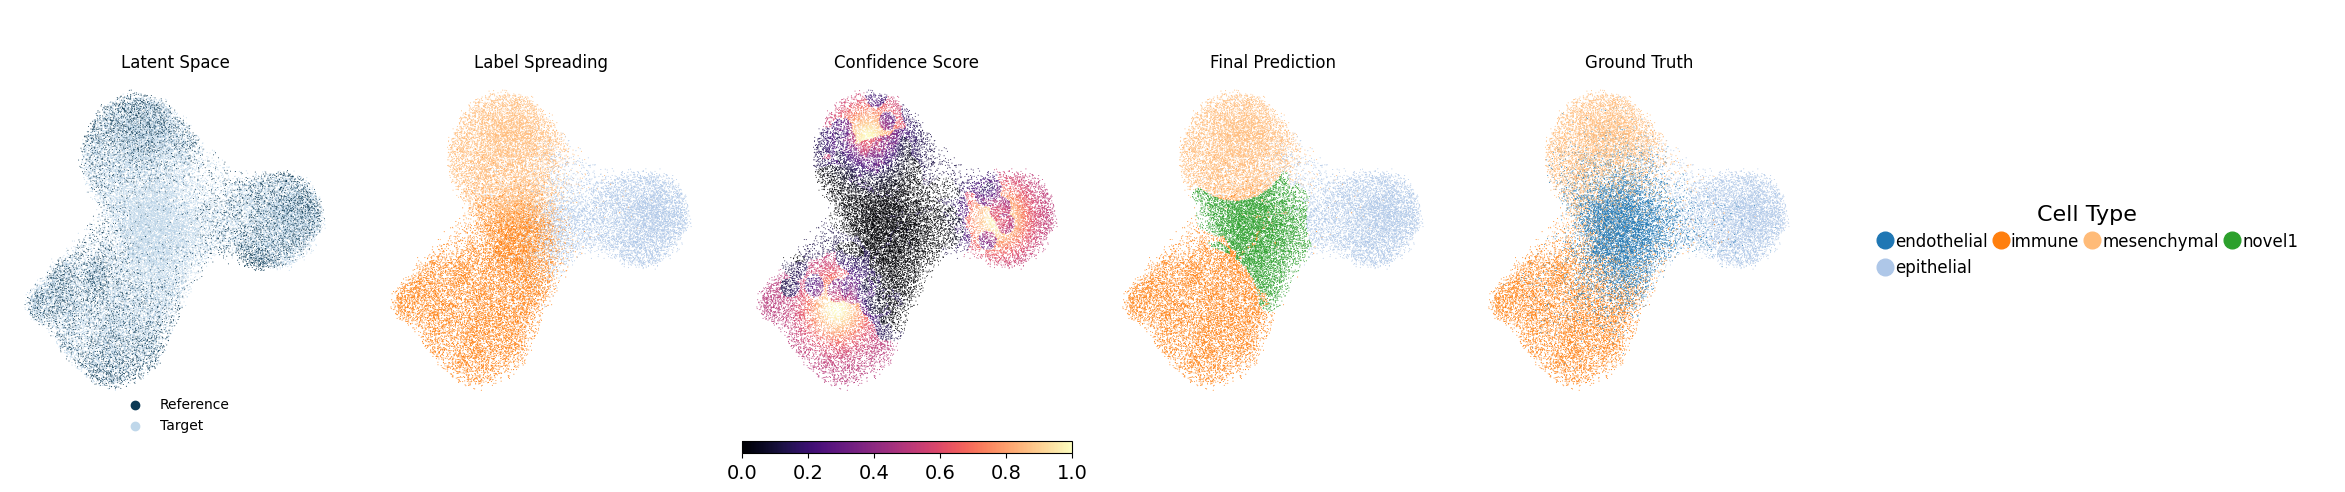

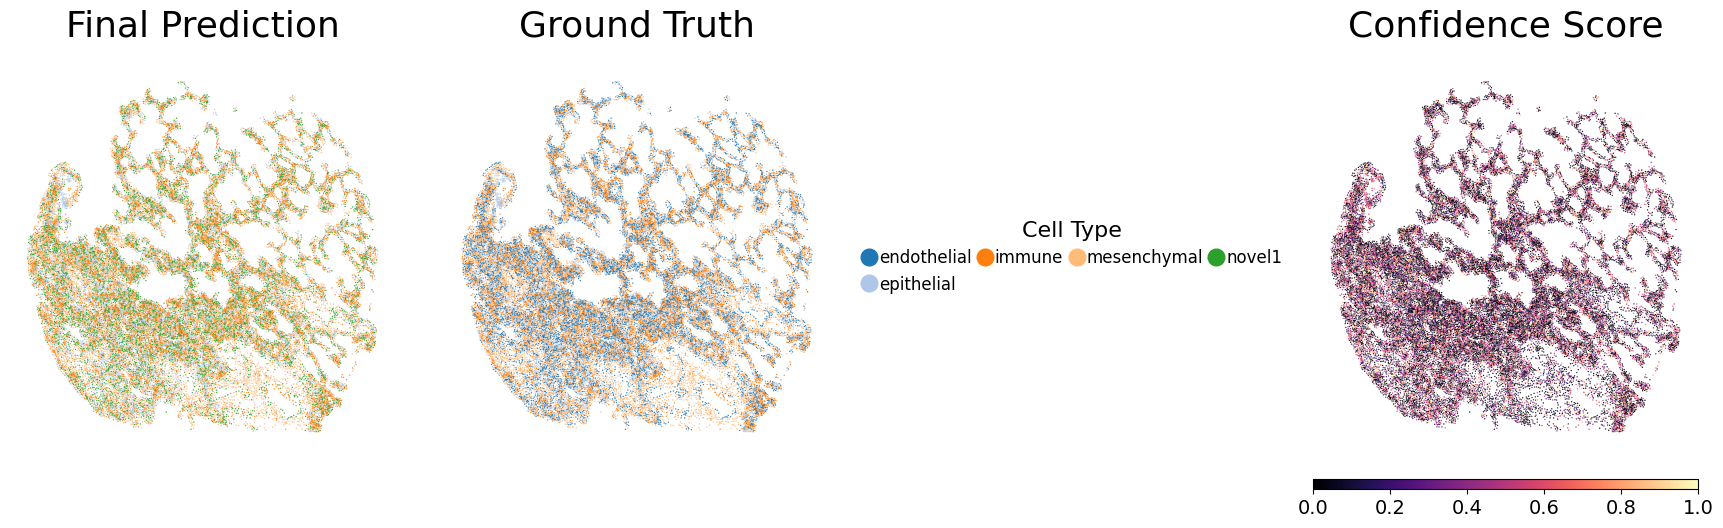

In [10]:
metrics_df = NovAST_evaluation(args)